# Análisis Exploratorio de Datos (EDA)

**Dataset:** `dataset_final_TFG.csv`  
**Período normales:** 2026-01-01 al 2026-02-11  
**Período amenazas:** 2026-01-05 al 2026-01-25 (dentro del período normal)  

---


> El `dataset_final_TFG.csv` **no contiene etiquetas**. El modelo nunca sabe qué registros son anómalos.
> En este notebook se usa `ground_truth_eventos.csv` **únicamente para visualización**: 
> se crea una columna temporal `is_anomaly` solo en memoria para verificar que los patrones anómalos son visualmente distinguibles antes de entrenar
> Esa columna **nunca se escribe en ningún CSV** ni entra en el modelo.

---
### Estructura del notebook
1. Carga y validación del dataset
2. Estadísticas descriptivas generales
3. Análisis temporal (patrones por hora, día, semana)
4. Análisis geográfico (países, sedes, NetworkType)
5. Análisis de operaciones y recursos
6. Análisis de usuarios (volumen, perfiles, dispositivos)
7. Análisis de las features ML generadas
8. Matriz de correlación
9. Conclusiones para el modelado

---
## 0. Instalación de dependencias

In [ ]:
# Instalamos si no tenemos
# !pip install pandas numpy matplotlib seaborn plotly scipy

---
## 1. Carga y Validación del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PALETTE_MAIN  = ['#1F4E79', '#2E75B6', '#9DC3E6', '#C55A11', '#FF0000']
COLOR_NORMAL  = '#2E75B6'
COLOR_ANOMALY = '#C00000'
COLOR_WARN    = '#C55A11'

# ── Rutas ──────────────────────────────────────────────────────
PATH_DATASET      = '../Data/dataset_final_TFG.csv'
PATH_GROUND_TRUTH = '../Data/ground_truth_eventos.csv'
OUTPUT_DIR        = '../EDA_Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente ✅


In [ ]:
# ── Carga del dataset principal ────────────────────────────────
df = pd.read_csv(PATH_DATASET, parse_dates=['CustomTimestamp'])

# ── Carga del ground truth (para secciones de anomalías) ───────
gt = pd.read_csv(PATH_GROUND_TRUTH) if os.path.exists(PATH_GROUND_TRUTH) else None

# ── Validación de esquema ──────────────────────────────────────
COLUMNAS_ESPERADAS = [
    'CustomTimestamp','UserPrincipalName','Department','Office','Country',
    'Operation','Resource','Result','IP_Address','NetworkType',
    'Device_ID','Resource_Criticality','UserProfile',
    'Hour','DayOfWeek','IsOfficeHours','IsWeekend','IsUnknownDevice',
    'IsExternalNetwork','IsHighCriticality','IsFailedOrDenied',
    'IsWriteOrDelete','DailyOpsVolume','UniqueCountriesPerDay','UniqueContainersPerDay'
]

faltantes = [c for c in COLUMNAS_ESPERADAS if c not in df.columns]
if faltantes:
    print(f'  Columnas faltantes: {faltantes}')
    print('   Asegúrate de haber ejecutado Union_logs.py antes del EDA.')
else:
    print(f' Esquema validado — {len(df.columns)} columnas encontradas')

# ── Añadir flag de anomalía si hay ground truth ────────────────
if gt is not None:
    df['_join_key'] = df['CustomTimestamp'].astype(str) + '|' + df['UserPrincipalName']
    gt_keys = set(gt['CustomTimestamp'].astype(str) + '|' + gt['UserPrincipalName'])
    df['is_anomaly'] = df['_join_key'].isin(gt_keys).astype(int)
else:
    df['is_anomaly'] = 0
    print('  Ground truth no disponible — ejecuta Generate-ThreatLogs_v4.ps1 primero')

print(f'\nDataset cargado: {len(df):,} registros × {len(df.columns)} columnas')
print(f'Período: {df["CustomTimestamp"].min()} → {df["CustomTimestamp"].max()}')

✅ Esquema validado — 25 columnas encontradas

Dataset cargado: 427,419 registros × 27 columnas
Período: 2026-01-01 00:00:26 → 2026-02-11 23:58:47


In [23]:
# ── Vista previa ───────────────────────────────────────────────
df.head(10)

,CustomTimestamp,UserPrincipalName,Department,Office,Country,Operation,Resource,Result,IP_Address,NetworkType,...,IsUnknownDevice,IsExternalNetwork,IsHighCriticality,IsFailedOrDenied,IsWriteOrDelete,DailyOpsVolume,UniqueCountriesPerDay,UniqueContainersPerDay,_join_key,is_anomaly
0,2026-01-01 00:00:26,agnieszka.wisniewski@garciapablo933gmail.onmic...,marketing,Los Angeles,US,StorageRead,/marketing/campanas/,Success,10.7.1.167,Corporate,...,0,0,0,0,0,72,1,2,2026-01-01 00:00:26|agnieszka.wisniewski@garci...,0
1,2026-01-01 00:00:38,olivia.evans@garciapablo933gmail.onmicrosoft.com,shared,Los Angeles,US,StorageRead,/shared/plantillas/,Success,10.7.1.157,Corporate,...,0,0,0,0,0,44,1,1,2026-01-01 00:00:38|olivia.evans@garciapablo93...,0
2,2026-01-01 00:00:52,alessandro.bruno@garciapablo933gmail.onmicroso...,finanzas,Los Angeles,US,StorageRead,/shared/plantillas/,Success,10.7.1.156,Corporate,...,0,0,0,0,0,41,1,1,2026-01-01 00:00:52|alessandro.bruno@garciapab...,0
3,2026-01-01 00:00:55,isabella.brown@garciapablo933gmail.onmicrosoft...,shared,Los Angeles,US,StorageRead,/shared/plantillas/,Success,10.7.1.37,Corporate,...,0,0,0,0,0,44,1,1,2026-01-01 00:00:55|isabella.brown@garciapablo...,0
4,2026-01-01 00:01:25,agnieszka.wisniewski@garciapablo933gmail.onmic...,marketing,Los Angeles,US,StorageRead,/shared/plantillas/,Success,10.7.1.167,Corporate,...,0,0,0,0,0,72,1,2,2026-01-01 00:01:25|agnieszka.wisniewski@garci...,0
5,2026-01-01 00:01:27,alyssa.lee@garciapablo933gmail.onmicrosoft.com,marketing,Los Angeles,US,StorageRead,/marketing/campanas/,Success,10.7.1.53,Corporate,...,0,0,0,0,0,81,1,2,2026-01-01 00:01:27|alyssa.lee@garciapablo933g...,0
6,2026-01-01 00:01:29,sarah.davis@garciapablo933gmail.onmicrosoft.com,finanzas,Milan,IT,StorageRead,/shared/plantillas/,Success,10.4.1.247,Corporate,...,0,0,0,0,0,71,1,1,2026-01-01 00:01:29|sarah.davis@garciapablo933...,0
7,2026-01-01 00:01:34,melissa.miller@garciapablo933gmail.onmicrosoft...,shared,Los Angeles,US,StorageRead,/shared/plantillas/,Success,10.7.1.233,Corporate,...,0,0,0,0,0,18,1,1,2026-01-01 00:01:34|melissa.miller@garciapablo...,0
8,2026-01-01 00:01:56,sara.esposito@garciapablo933gmail.onmicrosoft.com,marketing,Los Angeles,US,StorageRead,/marketing/campanas/,Failed,172.16.7.250,VPN,...,0,0,0,1,0,41,1,2,2026-01-01 00:01:56|sara.esposito@garciapablo9...,0
9,2026-01-01 00:02:00,elena.gomez@garciapablo933gmail.onmicrosoft.com,shared,Los Angeles,US,StorageRead,/shared/,Success,10.7.1.59,Corporate,...,0,0,0,0,0,51,1,1,2026-01-01 00:02:00|elena.gomez@garciapablo933...,0


In [ ]:
# ── Tipos de datos y nulos ─────────────────────────────────────
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print('\n=== VALORES NULOS ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Sin valores nulos')

=== TIPOS DE DATOS ===
CustomTimestamp           datetime64[ns]
UserPrincipalName                 object
Department                        object
Office                            object
Country                           object
Operation                         object
Resource                          object
Result                            object
IP_Address                        object
NetworkType                       object
Device_ID                         object
Resource_Criticality              object
UserProfile                       object
Hour                               int64
DayOfWeek                          int64
IsOfficeHours                      int64
IsWeekend                          int64
IsUnknownDevice                    int64
IsExternalNetwork                  int64
IsHighCriticality                  int64
IsFailedOrDenied                   int64
IsWriteOrDelete                    int64
DailyOpsVolume                     int64
UniqueCountriesPerDay             

---
## 2. Estadísticas Descriptivas Generales

In [25]:
# ── Resumen cuantitativo ───────────────────────────────────────
cols_numericas = ['Hour','DayOfWeek','DailyOpsVolume','UniqueCountriesPerDay','UniqueContainersPerDay']
df[cols_numericas].describe().round(2)

,Hour,DayOfWeek,DailyOpsVolume,UniqueCountriesPerDay,UniqueContainersPerDay
count,427419.00,427419.00,427419.00,427419.00,427419.00
mean,13.14,1.98,65.36,1.11,1.33
std,4.92,1.52,91.80,0.45,0.79
min,0.00,0.00,1.00,1.00,1.00
25%,10.00,1.00,40.00,1.00,1.00
50%,13.00,2.00,50.00,1.00,1.00
75%,16.00,3.00,70.00,1.00,1.00
max,23.00,6.00,804.00,4.00,6.00


In [26]:
# ── Dashboard de métricas clave ────────────────────────────────
total       = len(df)
n_usuarios  = df['UserPrincipalName'].nunique()
n_normales  = (df['is_anomaly'] == 0).sum()
n_anomalos  = (df['is_anomaly'] == 1).sum()
pct_anomaly = n_anomalos / total * 100
n_paises    = df['Country'].nunique()
n_sedes     = df['Office'].nunique()

metricas = {
    'Total registros':          f'{total:,}',
    'Usuarios únicos':          f'{n_usuarios}',
    'Registros normales':       f'{n_normales:,} ({100-pct_anomaly:.1f}%)',
    'Registros anómalos':       f'{n_anomalos:,} ({pct_anomaly:.1f}%)',
    'Países distintos':         f'{n_paises}',
    'Sedes/Oficinas':           f'{n_sedes}',
    'Operaciones distintas':    f'{df["Operation"].nunique()}',
    'Recursos distintos':       f'{df["Resource"].nunique()}',
}

print('\n' + '='*50)
print('  MÉTRICAS GENERALES DEL DATASET')
print('='*50)
for k, v in metricas.items():
    print(f'  {k:<30} {v}')
print('='*50)


  MÉTRICAS GENERALES DEL DATASET
  Total registros                427,419
  Usuarios únicos                300
  Registros normales             406,171 (95.0%)
  Registros anómalos             21,248 (5.0%)
  Países distintos               13
  Sedes/Oficinas                 8
  Operaciones distintas          3
  Recursos distintos             6908


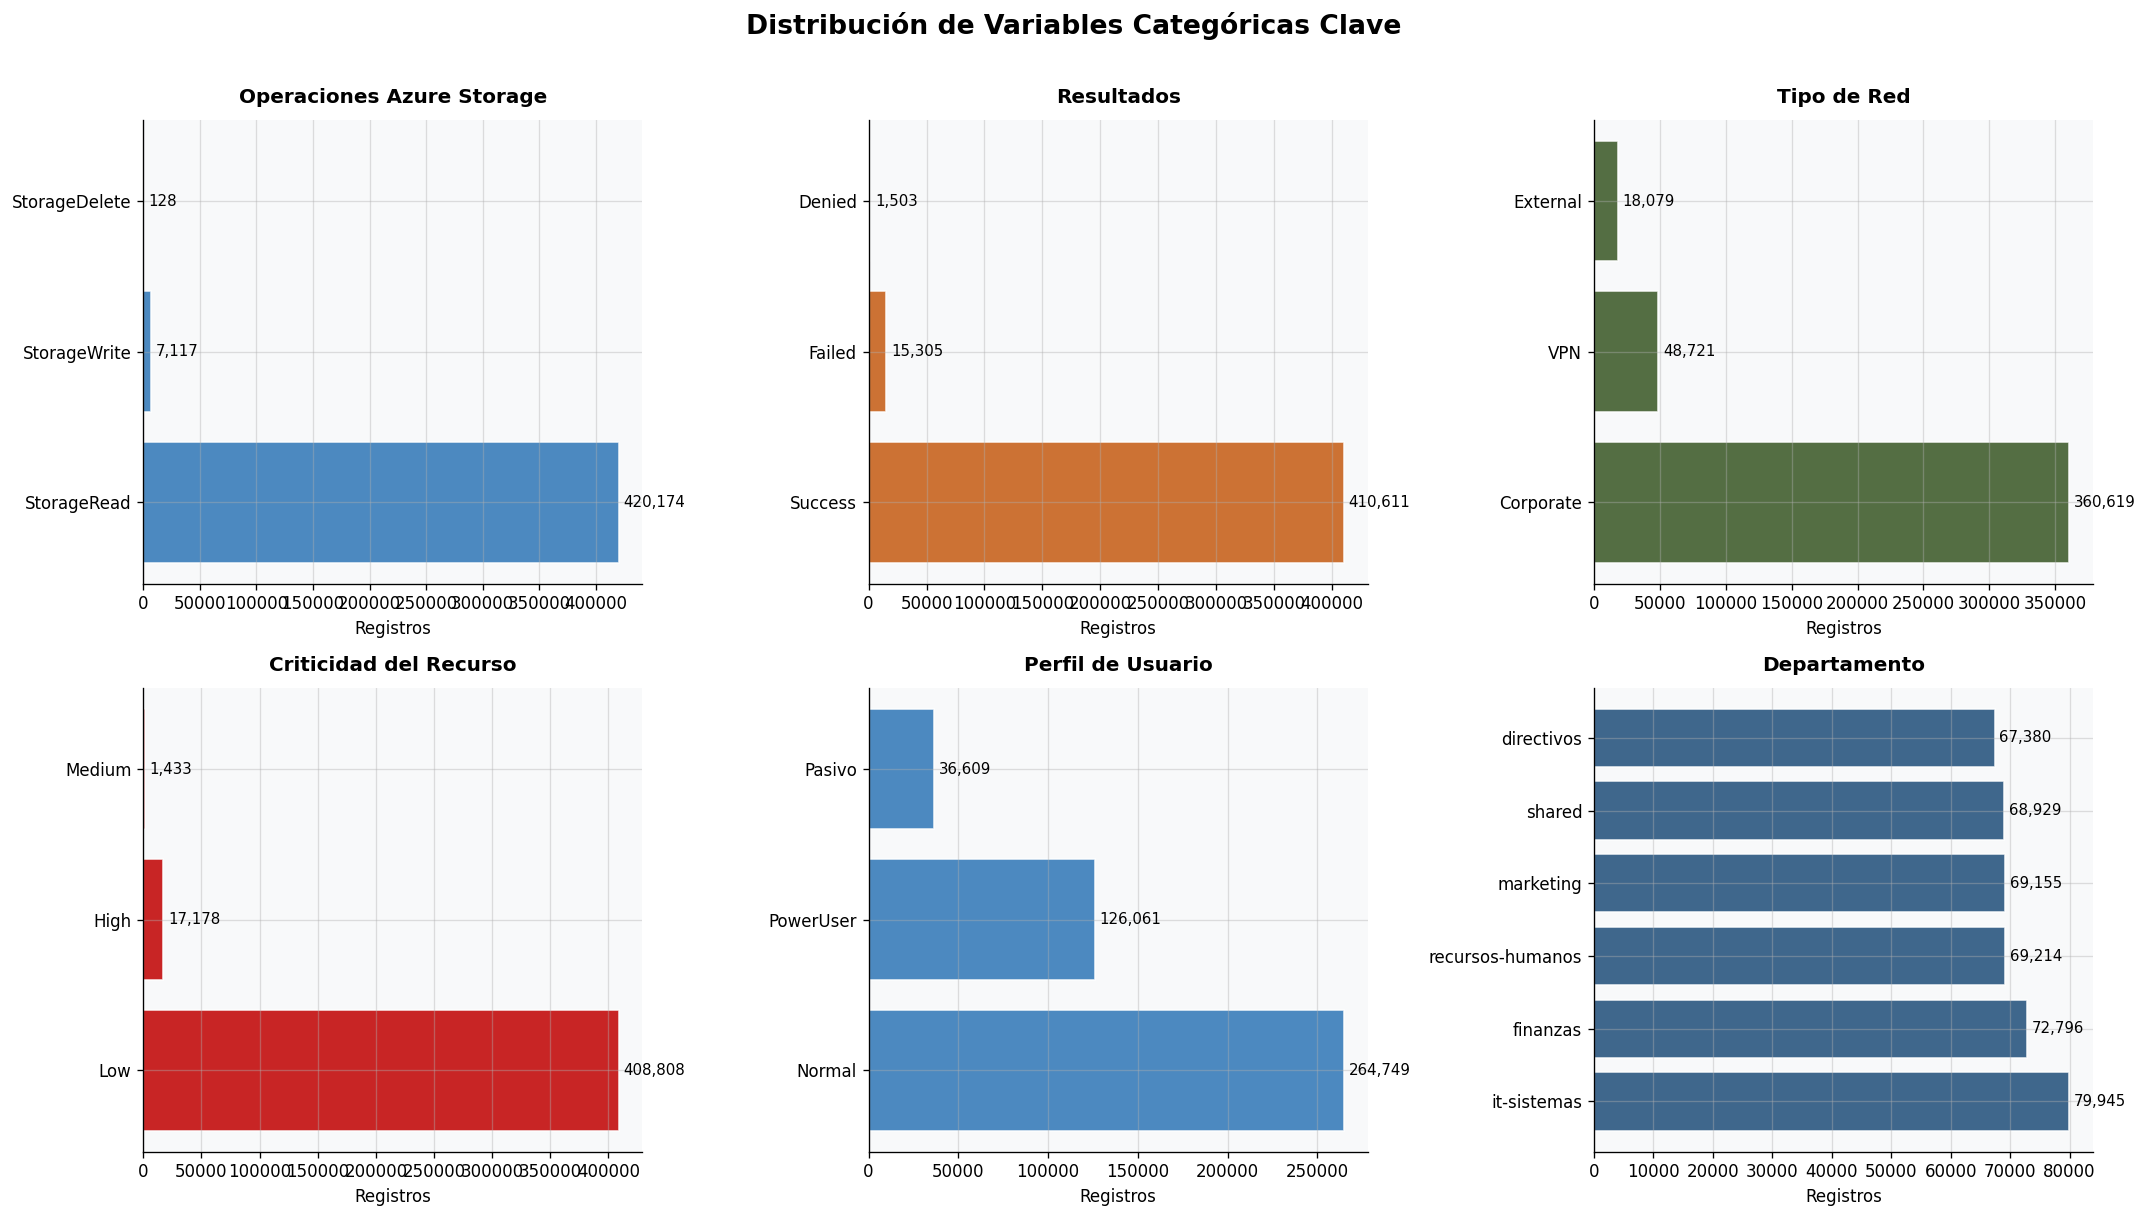

In [27]:
# ── Distribución de variables categóricas ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Variables Categóricas Clave', fontsize=16, fontweight='bold', y=1.01)

cats = [
    ('Operation',          'Operaciones Azure Storage',    COLOR_NORMAL),
    ('Result',             'Resultados',                   COLOR_WARN),
    ('NetworkType',        'Tipo de Red',                  '#375623'),
    ('Resource_Criticality','Criticidad del Recurso',      COLOR_ANOMALY),
    ('UserProfile',        'Perfil de Usuario',            PALETTE_MAIN[1]),
    ('Department',         'Departamento',                 PALETTE_MAIN[0]),
]

for ax, (col, title, color) in zip(axes.flat, cats):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Registros')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + max(counts.values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_distribucion_categoricas.png', bbox_inches='tight')
plt.show()

---
## 3. Análisis Temporal

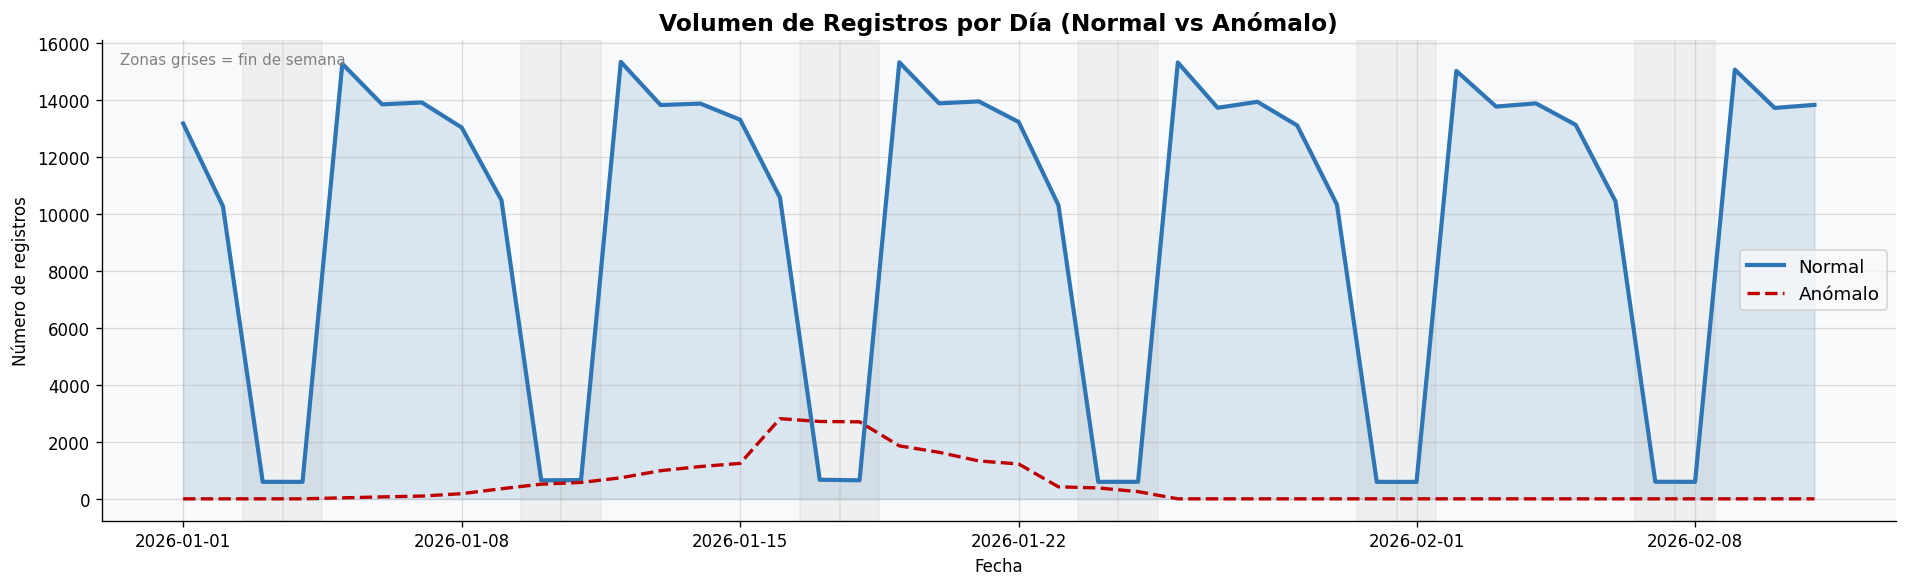

In [28]:
# ── Volumen de registros por día ───────────────────────────────
df['Date'] = df['CustomTimestamp'].dt.date
vol_dia = df.groupby(['Date','is_anomaly']).size().unstack(fill_value=0)
vol_dia.columns = ['Normal','Anómalo']

fig, ax = plt.subplots(figsize=(16, 5))
vol_dia['Normal'].plot(ax=ax, color=COLOR_NORMAL, linewidth=2.5, label='Normal', zorder=3)
vol_dia['Anómalo'].plot(ax=ax, color=COLOR_ANOMALY, linewidth=2, linestyle='--', label='Anómalo', zorder=4)
ax.fill_between(vol_dia.index, vol_dia['Normal'], alpha=0.15, color=COLOR_NORMAL)

# Marcar fines de semana
for date in vol_dia.index:
    if pd.Timestamp(date).dayofweek >= 5:
        ax.axvspan(pd.Timestamp(date) - pd.Timedelta(hours=12),
                   pd.Timestamp(date) + pd.Timedelta(hours=12),
                   alpha=0.08, color='gray', zorder=1)

ax.set_title('Volumen de Registros por Día (Normal vs Anómalo)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de registros')
ax.legend(fontsize=11)
ax.annotate('Zonas grises = fin de semana', xy=(0.01, 0.95), xycoords='axes fraction',
            fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_volumen_diario.png', bbox_inches='tight')
plt.show()

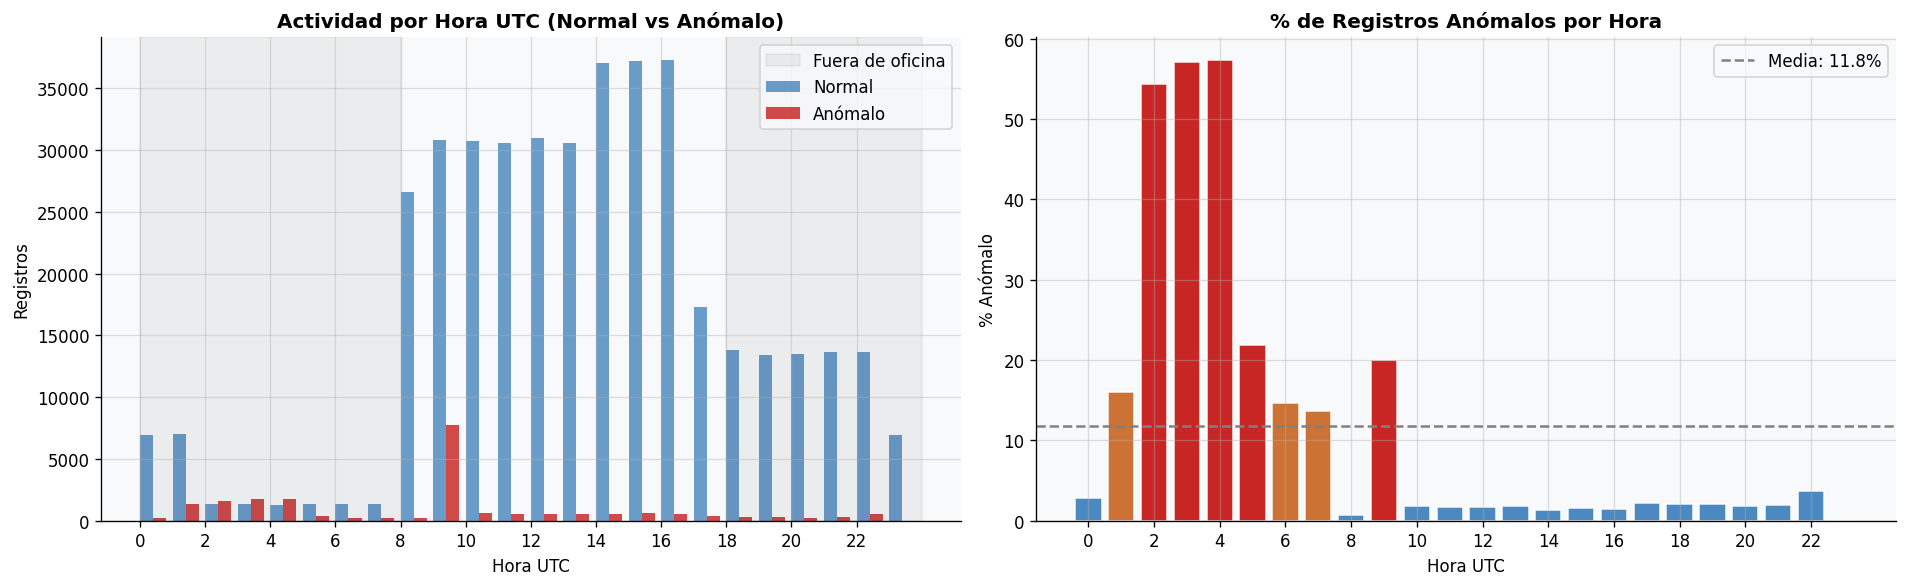


🔍 Horas con mayor ratio de anomalías:
Hour
4    57.34
3    57.14
2    54.38
5    21.88
9    20.06


In [ ]:
# ── Distribución por hora del día ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Normal vs Anómalo por hora
hora_normal  = df[df['is_anomaly']==0]['Hour'].value_counts().sort_index()
hora_anomalo = df[df['is_anomaly']==1]['Hour'].value_counts().sort_index()

axes[0].bar(hora_normal.index,  hora_normal.values,  color=COLOR_NORMAL,  alpha=0.7, label='Normal',  width=0.4, align='edge')
axes[0].bar(hora_anomalo.index + 0.4, hora_anomalo.values, color=COLOR_ANOMALY, alpha=0.7, label='Anómalo', width=0.4, align='edge')
axes[0].axvspan(0, 8,  alpha=0.05, color='black', label='Fuera de oficina')
axes[0].axvspan(18, 24, alpha=0.05, color='black')
axes[0].set_title('Actividad por Hora UTC (Normal vs Anómalo)', fontweight='bold')
axes[0].set_xlabel('Hora UTC')
axes[0].set_ylabel('Registros')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Ratio de anomalías por hora
ratio_hora = df.groupby('Hour')['is_anomaly'].mean() * 100
colors_bar = [COLOR_ANOMALY if v > ratio_hora.mean()*1.5 else COLOR_WARN if v > ratio_hora.mean() else COLOR_NORMAL
              for v in ratio_hora.values]
axes[1].bar(ratio_hora.index, ratio_hora.values, color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].axhline(ratio_hora.mean(), color='gray', linestyle='--', linewidth=1.5, label=f'Media: {ratio_hora.mean():.1f}%')
axes[1].set_title('% de Registros Anómalos por Hora', fontweight='bold')
axes[1].set_xlabel('Hora UTC')
axes[1].set_ylabel('% Anómalo')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_actividad_por_hora.png', bbox_inches='tight')
plt.show()

print('\n Horas con mayor ratio de anomalías:')
print(ratio_hora.nlargest(5).round(2).to_string())

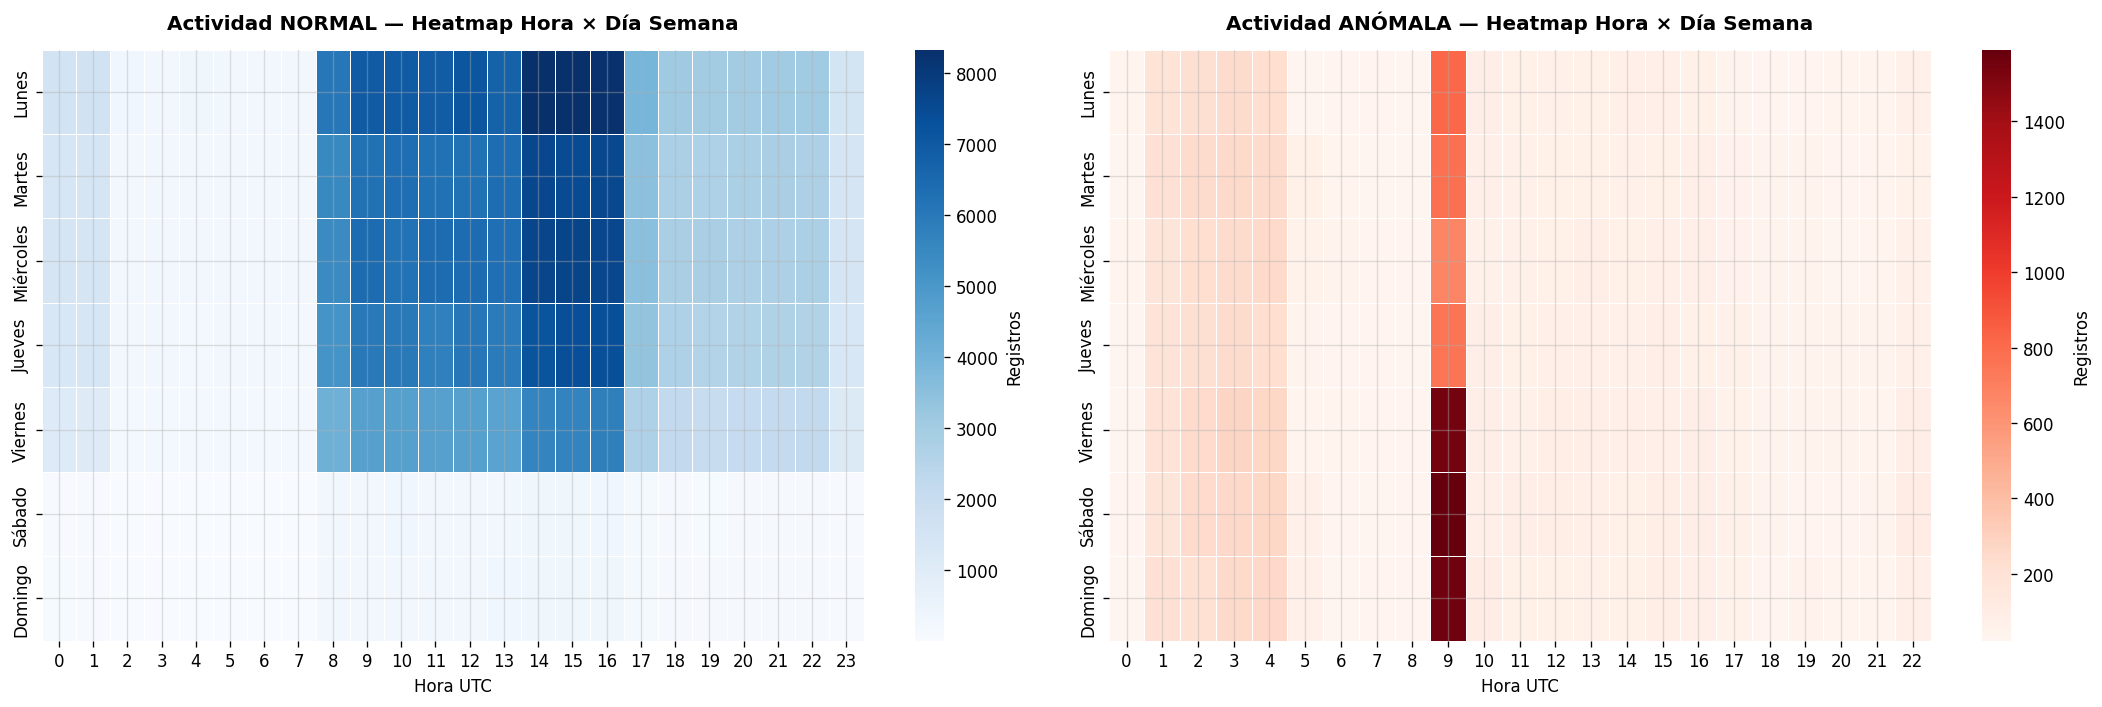

In [30]:
# ── Heatmap de actividad hora × día de semana ─────────────────
dias_labels = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (subset, title) in enumerate([
    (df[df['is_anomaly']==0], 'Actividad NORMAL — Heatmap Hora × Día Semana'),
    (df[df['is_anomaly']==1], 'Actividad ANÓMALA — Heatmap Hora × Día Semana'),
]):
    pivot = subset.groupby(['DayOfWeek','Hour']).size().unstack(fill_value=0)
    pivot.index = [dias_labels[i] for i in pivot.index]
    cmap = 'Blues' if idx == 0 else 'Reds'
    sns.heatmap(pivot, ax=axes[idx], cmap=cmap, linewidths=0.3,
                cbar_kws={'label': 'Registros'}, fmt='d')
    axes[idx].set_title(title, fontweight='bold', pad=12)
    axes[idx].set_xlabel('Hora UTC')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_heatmap_hora_dia.png', bbox_inches='tight')
plt.show()

---
## 4. Análisis Geográfico

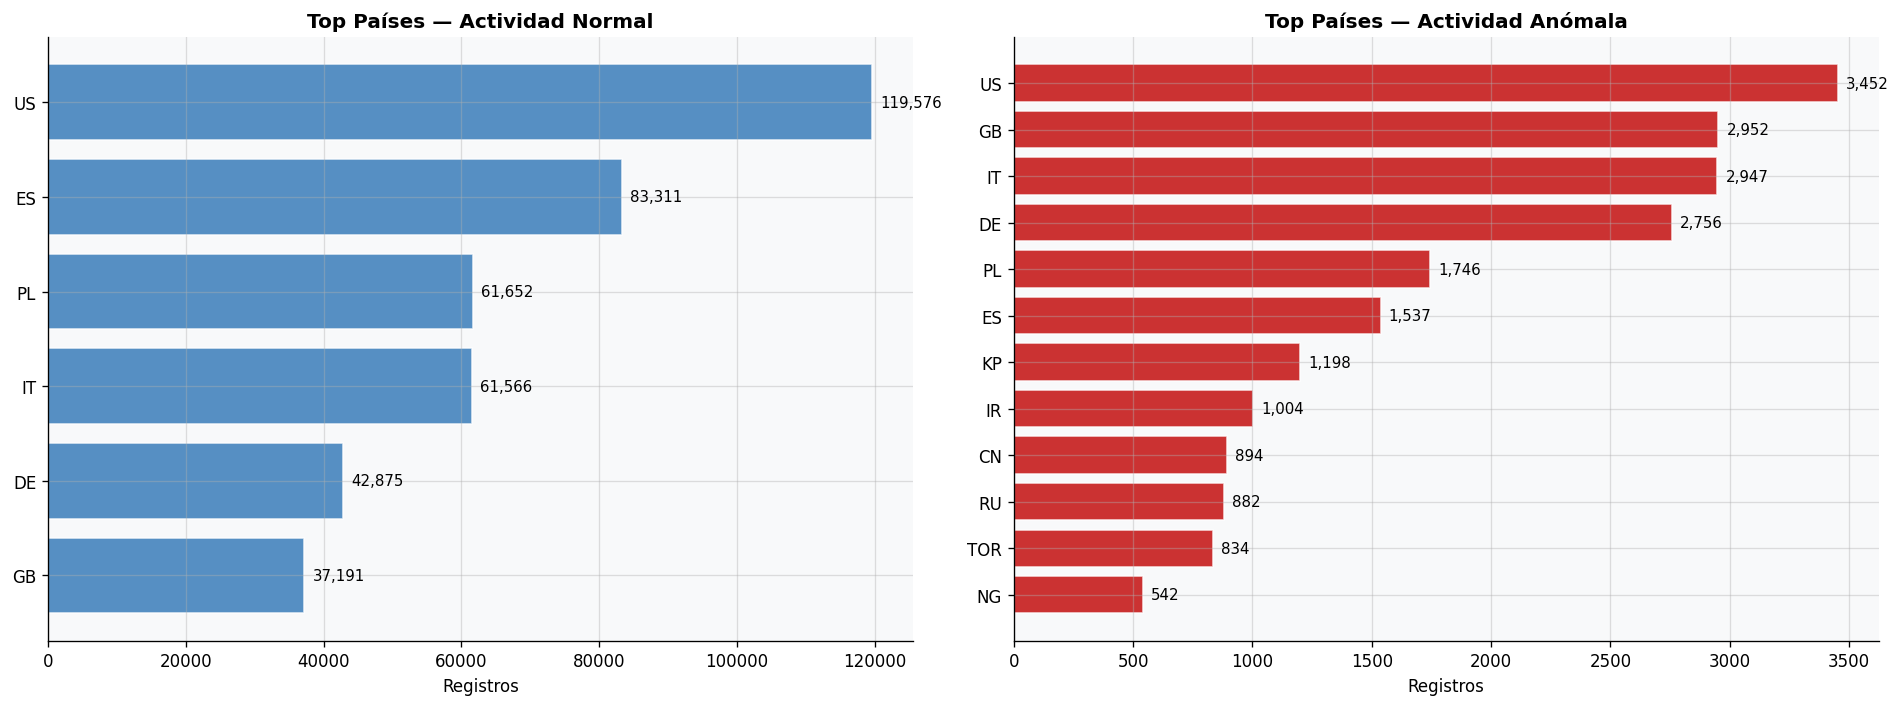

In [31]:
# ── Top países por actividad normal vs anómala ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (flag, title, color) in enumerate([
    (0, 'Top Países — Actividad Normal',  COLOR_NORMAL),
    (1, 'Top Países — Actividad Anómala', COLOR_ANOMALY),
]):
    counts = df[df['is_anomaly']==flag]['Country'].value_counts().head(12)
    axes[idx].barh(counts.index[::-1], counts.values[::-1], color=color, alpha=0.8, edgecolor='white')
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_xlabel('Registros')
    for i, (val, idx_bar) in enumerate(zip(counts.values[::-1], range(len(counts)))):
        axes[idx].text(val + max(counts.values)*0.01, idx_bar, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_paises.png', bbox_inches='tight')
plt.show()

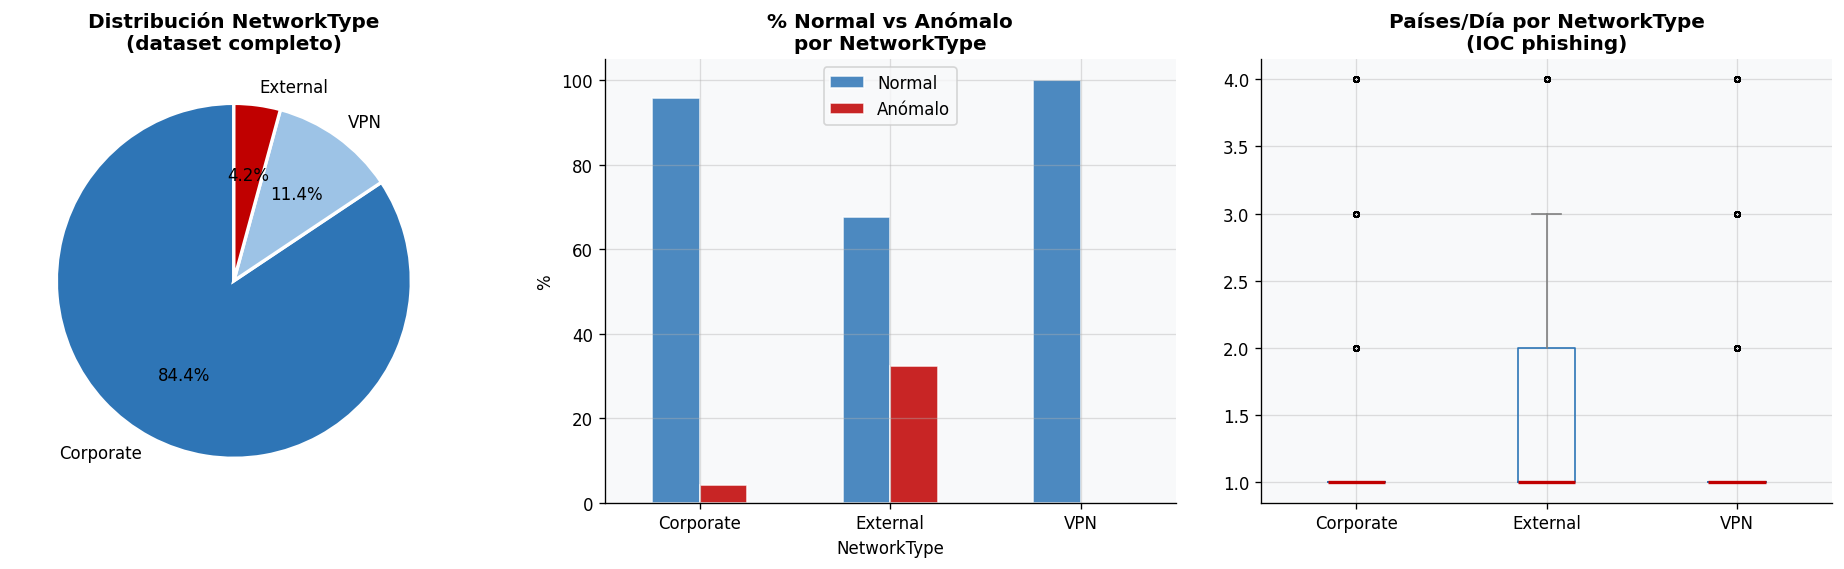

In [32]:
# ── NetworkType: distribución y ratio de anomalía ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart distribución general
net_counts = df['NetworkType'].value_counts()
colors_pie = [COLOR_NORMAL, '#9DC3E6', COLOR_ANOMALY]
axes[0].pie(net_counts.values, labels=net_counts.index, colors=colors_pie,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribución NetworkType\n(dataset completo)', fontweight='bold')

# Stacked bar normal vs anómalo por NetworkType
net_cross = pd.crosstab(df['NetworkType'], df['is_anomaly'], normalize='index') * 100
net_cross.columns = ['Normal','Anómalo']
net_cross[['Normal','Anómalo']].plot(kind='bar', ax=axes[1], color=[COLOR_NORMAL, COLOR_ANOMALY],
                                      alpha=0.85, edgecolor='white', rot=0)
axes[1].set_title('% Normal vs Anómalo\npor NetworkType', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()

# Boxplot UniqueCountriesPerDay por NetworkType
order_net = df['NetworkType'].value_counts().index
df.boxplot(column='UniqueCountriesPerDay', by='NetworkType', ax=axes[2],
           boxprops=dict(color=COLOR_NORMAL), medianprops=dict(color=COLOR_ANOMALY, linewidth=2),
           whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
           flierprops=dict(marker='o', color=COLOR_WARN, alpha=0.3, markersize=3))
axes[2].set_title('Países/Día por NetworkType\n(IOC phishing)', fontweight='bold')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_networktype.png', bbox_inches='tight')
plt.show()

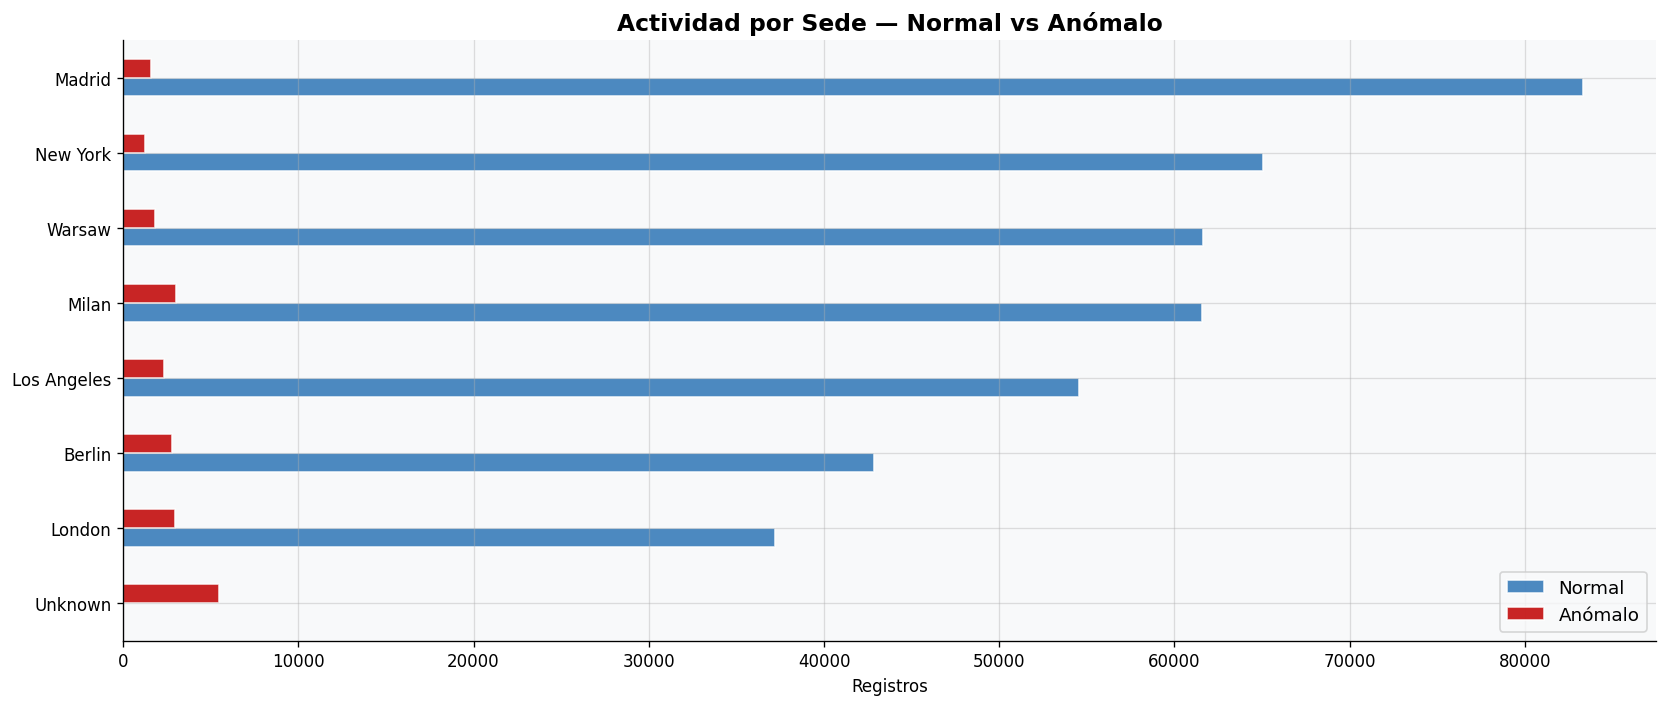

In [33]:
# ── Actividad por sede (Office) ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

office_cross = pd.crosstab(df['Office'], df['is_anomaly'])
office_cross.columns = ['Normal','Anómalo']
office_cross = office_cross.sort_values('Normal', ascending=True)

office_cross.plot(kind='barh', ax=ax, color=[COLOR_NORMAL, COLOR_ANOMALY],
                  alpha=0.85, edgecolor='white', stacked=False)
ax.set_title('Actividad por Sede — Normal vs Anómalo', fontsize=14, fontweight='bold')
ax.set_xlabel('Registros')
ax.set_ylabel('')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_actividad_sede.png', bbox_inches='tight')
plt.show()

---
## 5.Análisis de Operaciones y Recursos

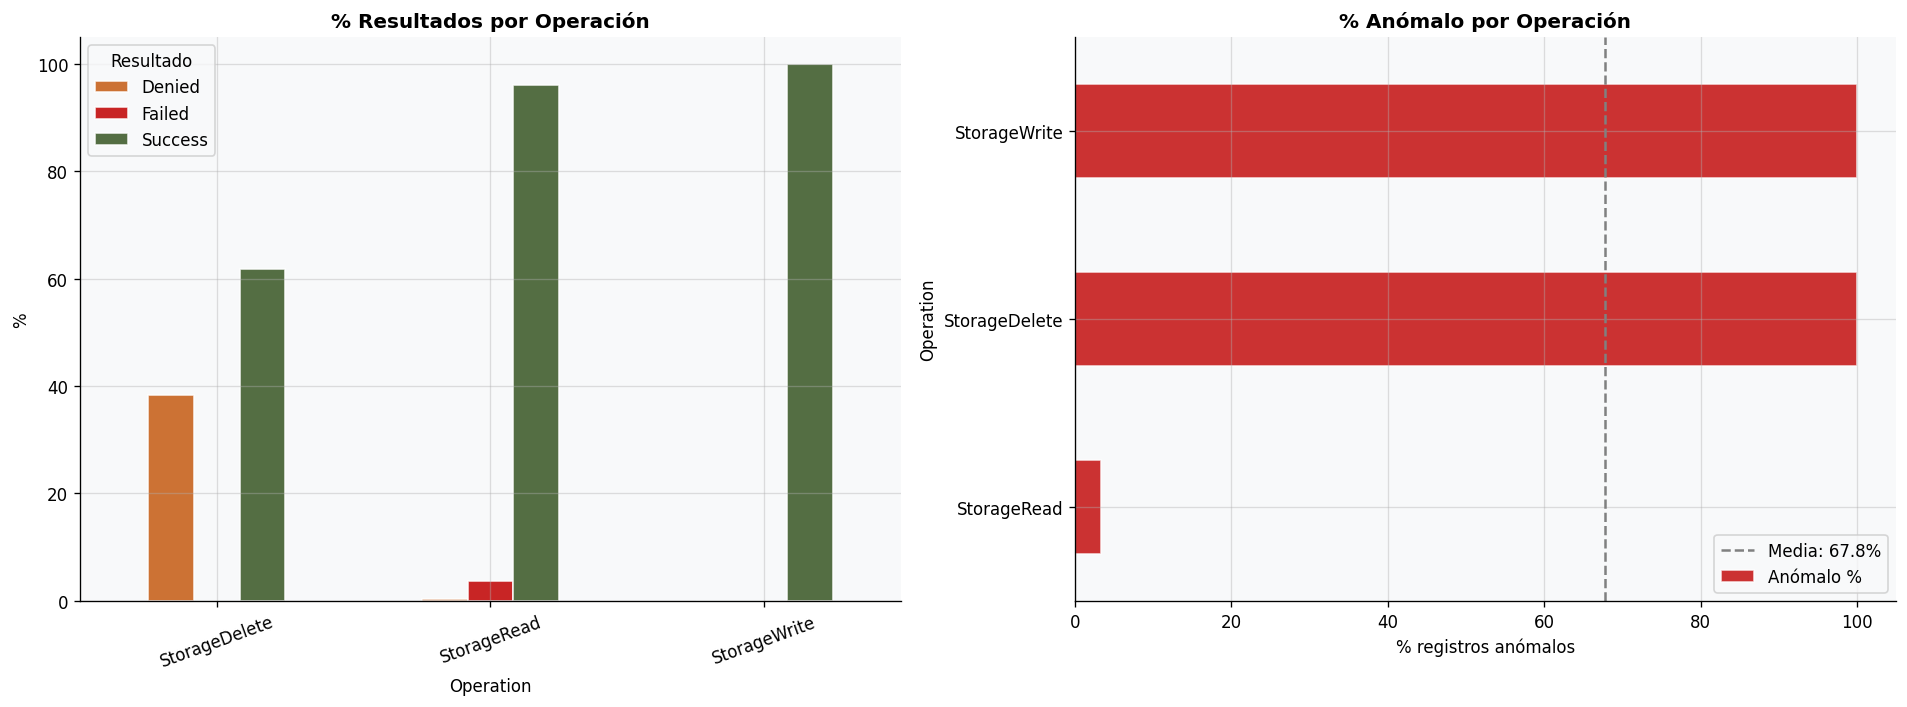

In [34]:
# ── Operaciones por tipo y resultado ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cross operación × resultado
op_result = pd.crosstab(df['Operation'], df['Result'])
op_result_pct = op_result.div(op_result.sum(axis=1), axis=0) * 100
colors_result = {'Success': '#375623', 'Failed': COLOR_ANOMALY, 'Denied': COLOR_WARN}
op_result_pct.plot(kind='bar', ax=axes[0], color=[colors_result.get(c, 'gray') for c in op_result_pct.columns],
                   alpha=0.85, edgecolor='white', rot=20)
axes[0].set_title('% Resultados por Operación', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].legend(title='Resultado')

# Operaciones anómalas vs normales
op_cross = pd.crosstab(df['Operation'], df['is_anomaly'], normalize='index') * 100
if 1 in op_cross.columns:
    op_cross.columns = ['Normal %','Anómalo %']
    op_cross['Anómalo %'].sort_values().plot(kind='barh', ax=axes[1],
                                              color=COLOR_ANOMALY, alpha=0.8, edgecolor='white')
    axes[1].axvline(op_cross['Anómalo %'].mean(), color='gray', linestyle='--',
                    label=f'Media: {op_cross["Anómalo %"].mean():.1f}%')
    axes[1].set_title('% Anómalo por Operación', fontweight='bold')
    axes[1].set_xlabel('% registros anómalos')
    axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_operaciones.png', bbox_inches='tight')
plt.show()

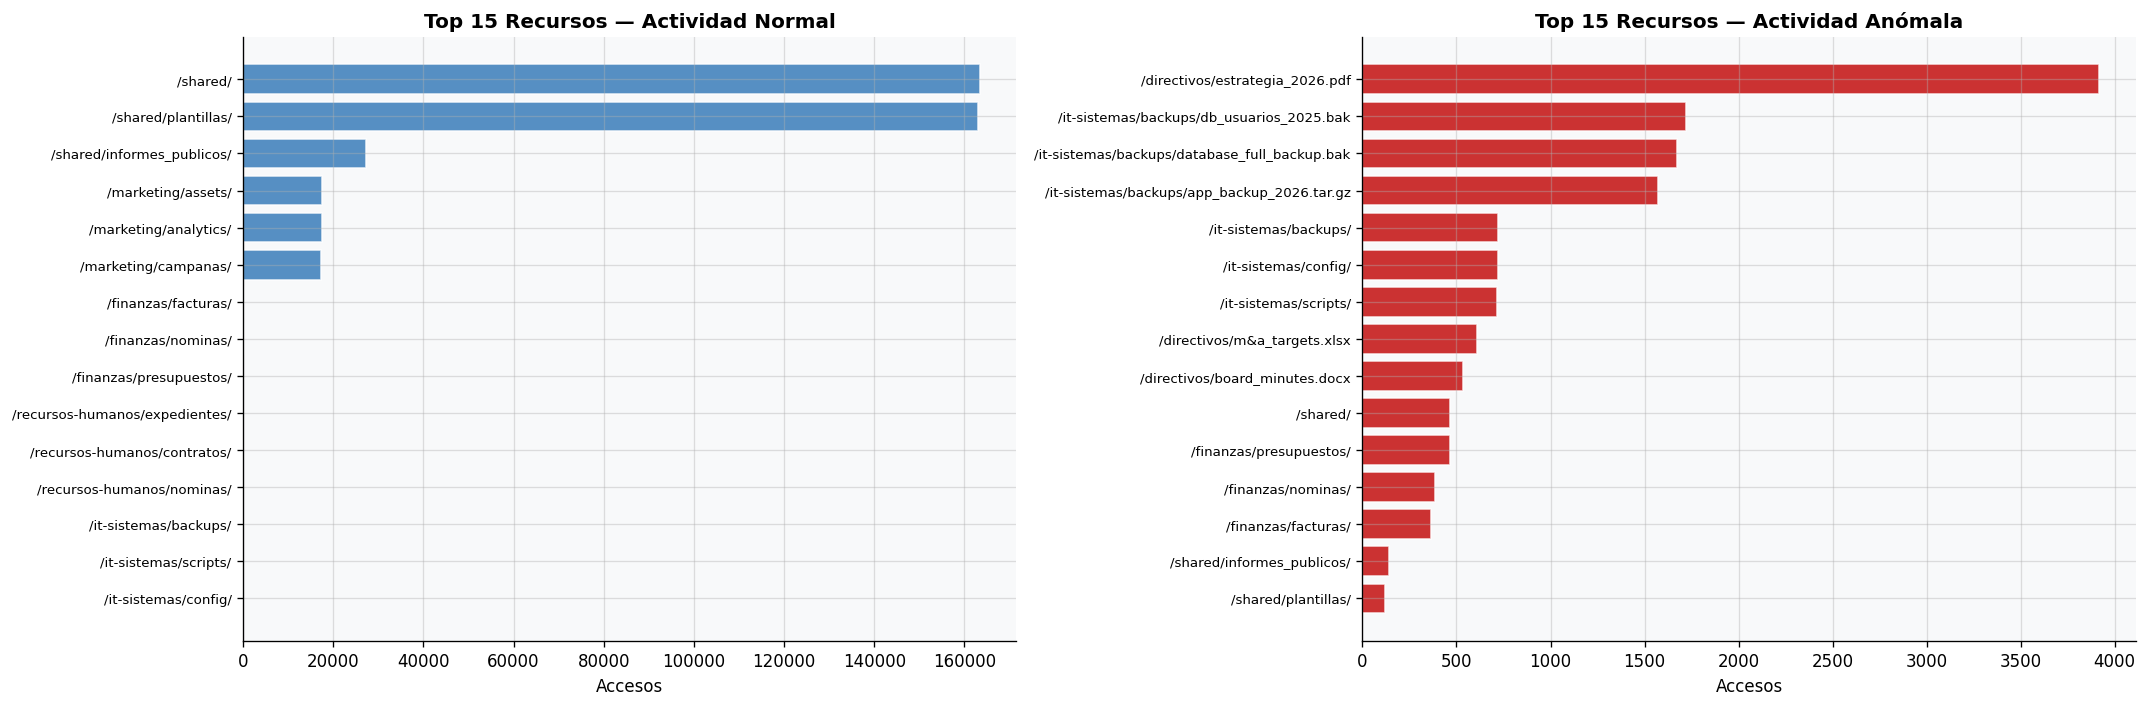

In [35]:
# ── Top recursos accedidos ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (flag, title, color) in enumerate([
    (0, 'Top 15 Recursos — Actividad Normal',  COLOR_NORMAL),
    (1, 'Top 15 Recursos — Actividad Anómala', COLOR_ANOMALY),
]):
    top_res = df[df['is_anomaly']==flag]['Resource'].value_counts().head(15)
    axes[idx].barh(range(len(top_res)), top_res.values[::-1], color=color, alpha=0.8, edgecolor='white')
    axes[idx].set_yticks(range(len(top_res)))
    axes[idx].set_yticklabels([r[:45] for r in top_res.index[::-1]], fontsize=8)
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_xlabel('Accesos')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_recursos.png', bbox_inches='tight')
plt.show()

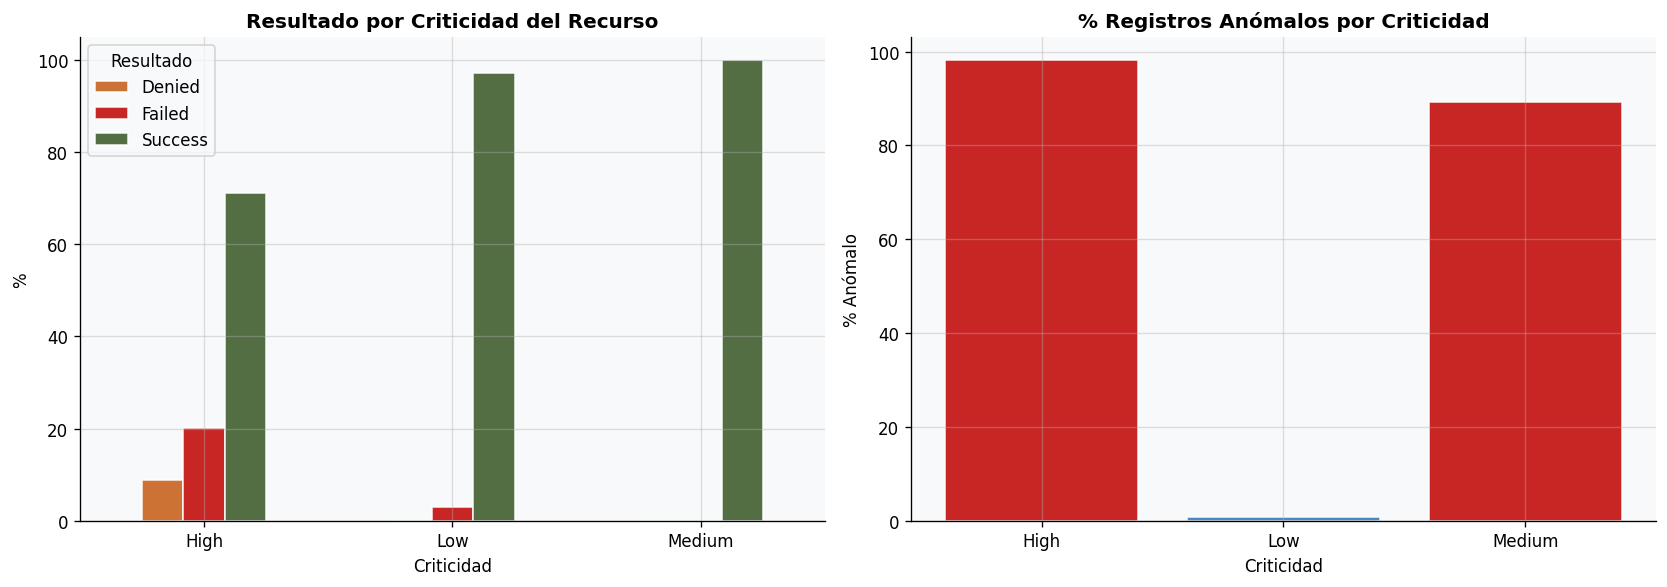

In [36]:
# ── Criticidad del recurso vs resultado ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crit_result = pd.crosstab(df['Resource_Criticality'], df['Result'])
crit_result_pct = crit_result.div(crit_result.sum(axis=1), axis=0) * 100
crit_result_pct.plot(kind='bar', ax=axes[0],
                     color=[colors_result.get(c,'gray') for c in crit_result_pct.columns],
                     alpha=0.85, edgecolor='white', rot=0)
axes[0].set_title('Resultado por Criticidad del Recurso', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_xlabel('Criticidad')
axes[0].legend(title='Resultado')

crit_anomaly = df.groupby('Resource_Criticality')['is_anomaly'].mean() * 100
colors_crit = [COLOR_ANOMALY if v > 10 else COLOR_WARN if v > 5 else COLOR_NORMAL
               for v in crit_anomaly.values]
axes[1].bar(crit_anomaly.index, crit_anomaly.values, color=colors_crit, alpha=0.85, edgecolor='white')
axes[1].set_title('% Registros Anómalos por Criticidad', fontweight='bold')
axes[1].set_ylabel('% Anómalo')
axes[1].set_xlabel('Criticidad')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_criticidad.png', bbox_inches='tight')
plt.show()

---
## 6.Análisis de Usuarios

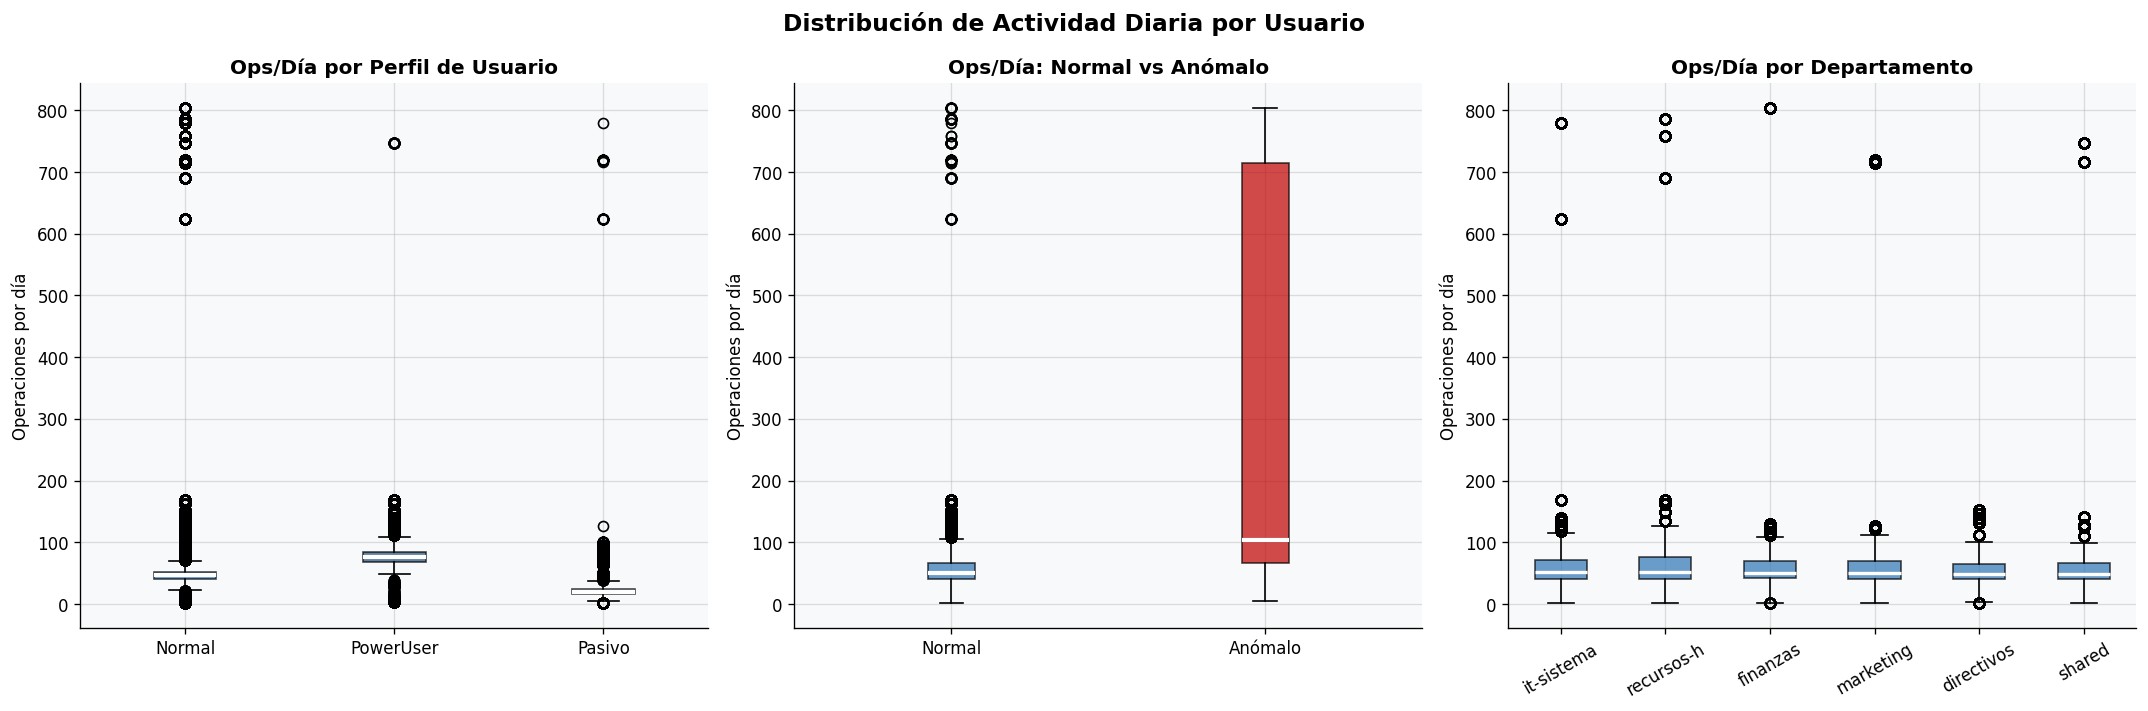

In [37]:
# ── Distribución de actividad diaria por usuario (BOXPLOT CLAVE) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución de Actividad Diaria por Usuario', fontsize=14, fontweight='bold')

# 1. Boxplot DailyOpsVolume por perfil
perfiles = df['UserProfile'].unique()
data_perfil = [df[df['UserProfile']==p]['DailyOpsVolume'].values for p in ['Normal','PowerUser','Pasivo'] if p in perfiles]
labels_p = [p for p in ['Normal','PowerUser','Pasivo'] if p in perfiles]
bp1 = axes[0].boxplot(data_perfil, labels=labels_p, patch_artist=True, notch=False,
                      medianprops=dict(color='white', linewidth=2.5))
colors_box = [COLOR_NORMAL, PALETTE_MAIN[0], PALETTE_MAIN[2]]
for patch, color in zip(bp1['boxes'], colors_box[:len(bp1['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Ops/Día por Perfil de Usuario', fontweight='bold')
axes[0].set_ylabel('Operaciones por día')

# 2. Boxplot DailyOpsVolume normal vs anómalo
data_anom = [df[df['is_anomaly']==0]['DailyOpsVolume'].values,
             df[df['is_anomaly']==1]['DailyOpsVolume'].values]
bp2 = axes[1].boxplot(data_anom, labels=['Normal','Anómalo'], patch_artist=True, notch=False,
                      medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp2['boxes'], [COLOR_NORMAL, COLOR_ANOMALY]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Ops/Día: Normal vs Anómalo', fontweight='bold')
axes[1].set_ylabel('Operaciones por día')

# 3. Boxplot DailyOpsVolume por departamento
depts = df.groupby('Department')['DailyOpsVolume'].median().sort_values(ascending=False).index
data_dept = [df[df['Department']==d]['DailyOpsVolume'].values for d in depts]
bp3 = axes[2].boxplot(data_dept, labels=[d[:10] for d in depts], patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
for patch in bp3['boxes']:
    patch.set_facecolor(PALETTE_MAIN[1])
    patch.set_alpha(0.7)
axes[2].set_title('Ops/Día por Departamento', fontweight='bold')
axes[2].set_ylabel('Operaciones por día')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_boxplot_actividad_usuario.png', bbox_inches='tight')
plt.show()

---
## 7.Análisis de Features ML

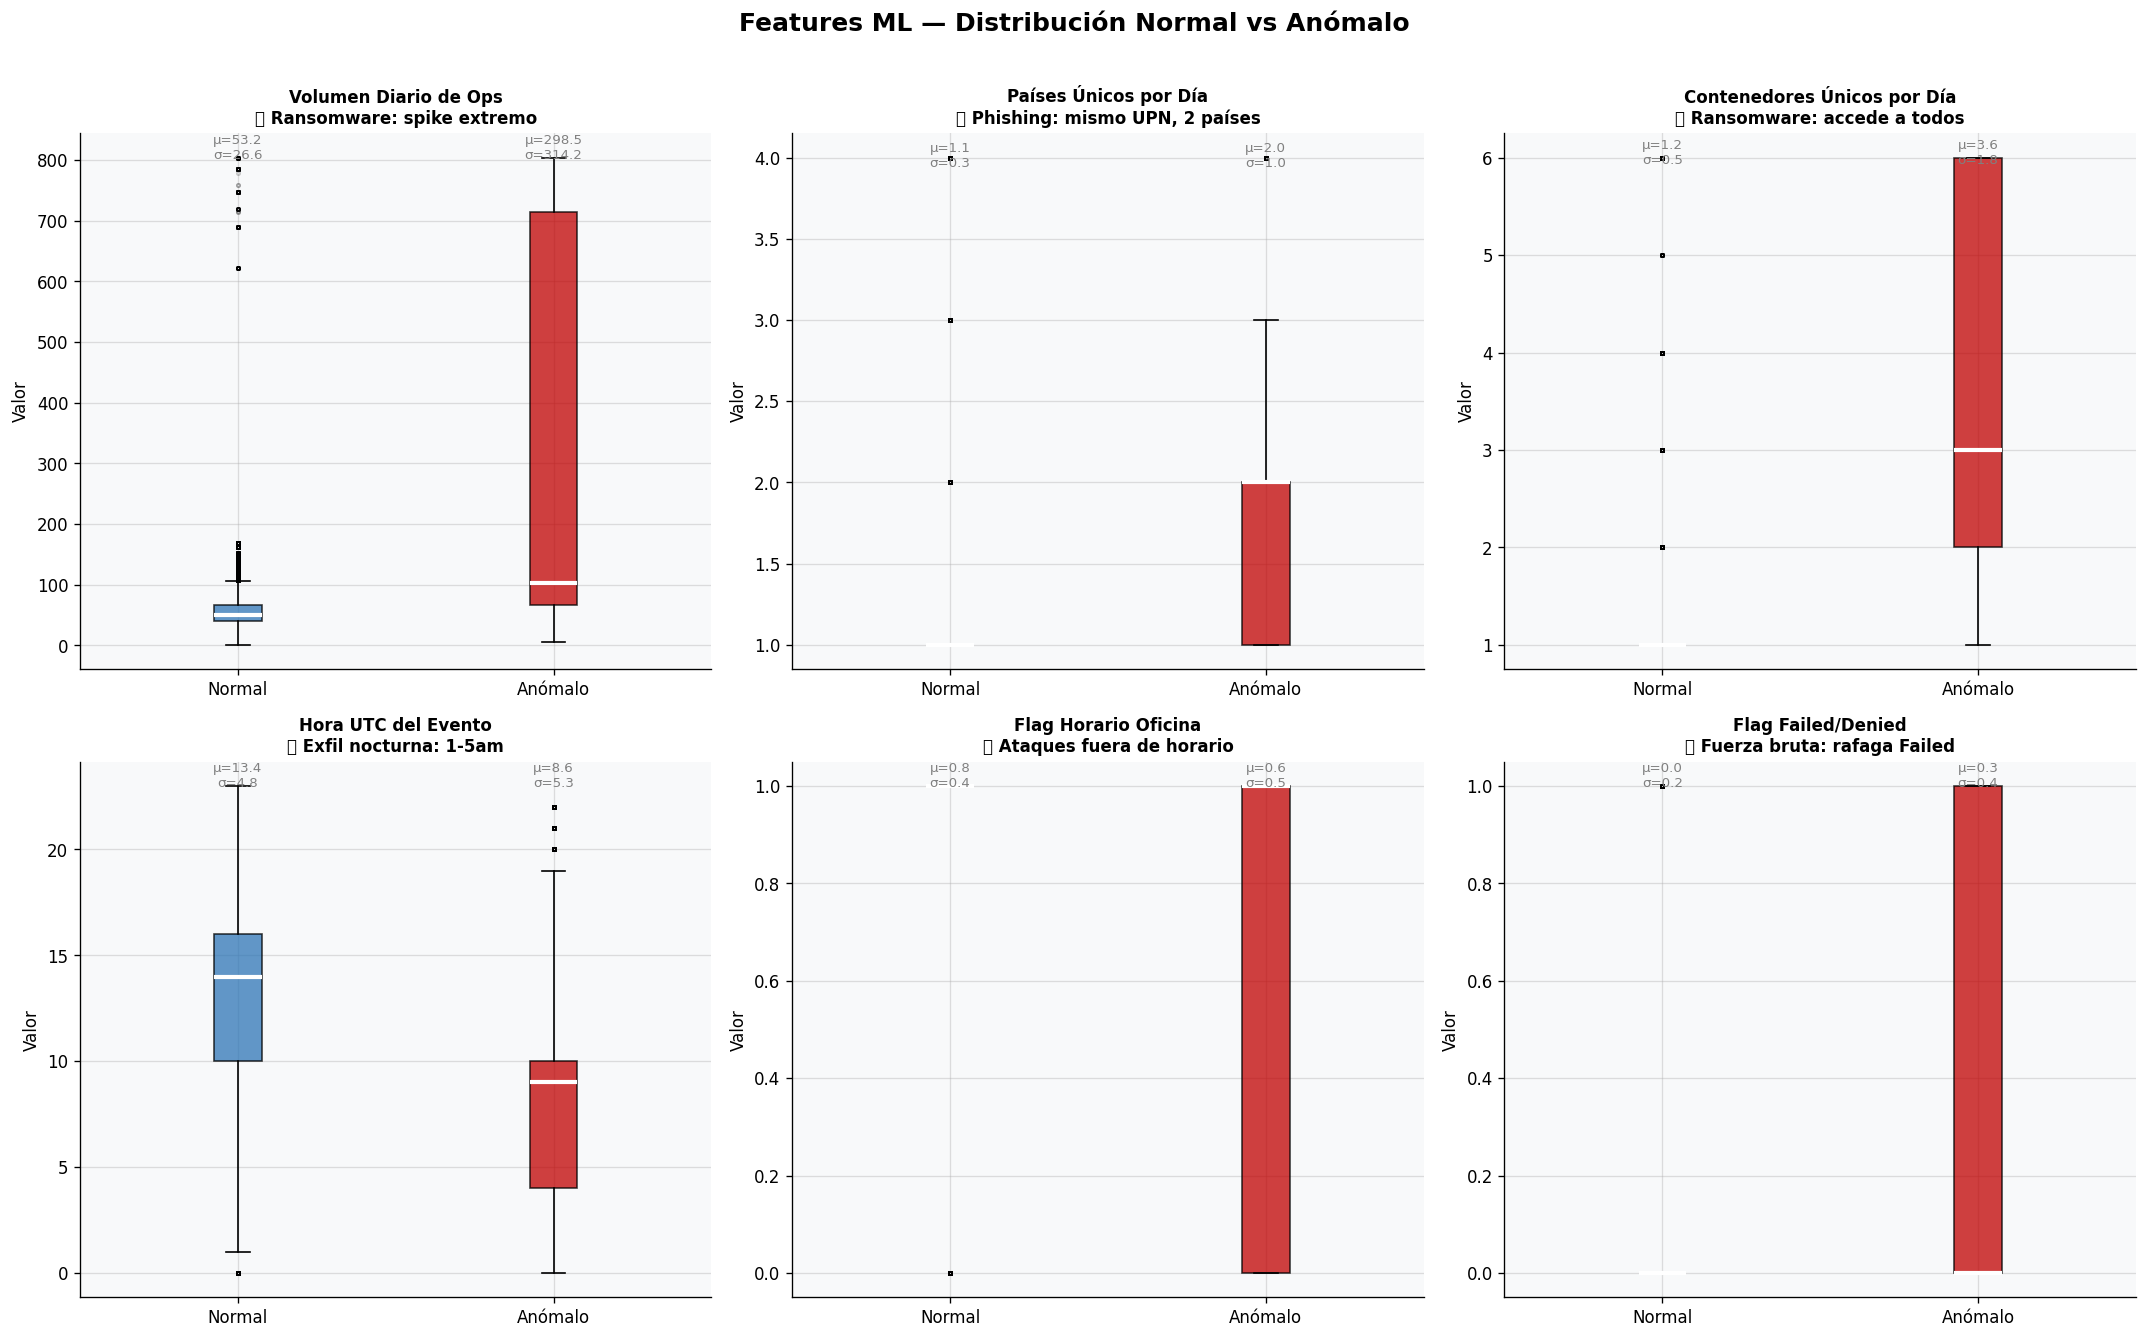

In [ ]:
# ── Boxplots de las 3 features más importantes para el modelo ──
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Features ML — Distribución Normal vs Anómalo', fontsize=15, fontweight='bold', y=1.01)

features_continuas = [
    ('DailyOpsVolume',          'Volumen Diario de Ops',         'Ransomware: spike extremo'),
    ('UniqueCountriesPerDay',   'Países Únicos por Día',         'Phishing: mismo UPN, 2 países'),
    ('UniqueContainersPerDay',  'Contenedores Únicos por Día',   'Ransomware: accede a todos'),
    ('Hour',                    'Hora UTC del Evento',           'Exfil nocturna: 1-5am'),
    ('IsOfficeHours',           'Flag Horario Oficina',          'Ataques fuera de horario'),
    ('IsFailedOrDenied',        'Flag Failed/Denied',            'Fuerza bruta: rafaga Failed'),
]

for ax, (feat, label, nota) in zip(axes.flat, features_continuas):
    data_n = df[df['is_anomaly']==0][feat].values
    data_a = df[df['is_anomaly']==1][feat].values

    bp = ax.boxplot([data_n, data_a], labels=['Normal','Anómalo'],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2.5),
                    flierprops=dict(marker='o', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], [COLOR_NORMAL, COLOR_ANOMALY]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(f'{label}\n{nota}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Valor')

    # Añadir estadísticas
    for i, (data, label_s) in enumerate([(data_n,'N'),(data_a,'A')], 1):
        ax.text(i, ax.get_ylim()[1]*0.95,
                f'μ={np.mean(data):.1f}\nσ={np.std(data):.1f}',
                ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_boxplots_features_ml.png', bbox_inches='tight')
plt.show()

---
## 8. Matriz de Correlación

In [2]:
# ── Correlación entre features numéricas e is_anomaly ─────────
features_corr = [
    'Hour','DayOfWeek','IsOfficeHours','IsWeekend',
    'IsUnknownDevice','IsExternalNetwork','IsHighCriticality',
    'IsFailedOrDenied','IsWriteOrDelete',
    'DailyOpsVolume','UniqueCountriesPerDay','UniqueContainersPerDay',
    'is_anomaly'
]

corr_matrix = df[features_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
            annot_kws={'size': 9})

ax.set_title('Matriz de Correlación — Features ML + is_anomaly', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/19_correlacion.png', bbox_inches='tight')
plt.show()

# Top correlaciones con is_anomaly
print('\nCorrelaciones con is_anomaly (ordenadas por importancia):')
corr_anomaly = corr_matrix['is_anomaly'].drop('is_anomaly').abs().sort_values(ascending=False)
for feat, val in corr_anomaly.items():
    direction = '↑' if corr_matrix.loc[feat,'is_anomaly'] > 0 else '↓'
    print(f'  {feat:<30} {direction}  {val:.4f}')

NameError: name 'df' is not defined

---
## 9. Conclusiones para el Modelado

In [ ]:
# ── Resumen estadístico normal vs anómalo ─────────────────────
print('='*65)
print('  RESUMEN EDA — CONCLUSIONES PARA ISOLATION FOREST / AUTOENCODER')
print('='*65)

resumen = df.groupby('is_anomaly')[features_corr[:-1]].mean().T
resumen.columns = ['Normal','Anómalo']
resumen['Ratio A/N'] = (resumen['Anómalo'] / resumen['Normal'].replace(0, np.nan)).round(2)
print(resumen.round(4).to_string())

print('\n' + '='*65)
print('  SEÑALES MÁS DISCRIMINANTES (para el modelo):')
print('='*65)

señales = [
    ('UniqueCountriesPerDay > 1',    'IOC Phishing — mismo UPN desde 2 países el mismo día'),
    ('UniqueContainersPerDay == 6',  'IOC Ransomware — accede a TODOS los contenedores'),
    ('DailyOpsVolume extremo',       'IOC Ransomware — ráfaga de escritura en <30 min'),
    ('IsUnknownDevice = 1',          'IOC BF/Phishing/GeoAnom — dispositivo no corporativo'),
    ('IsExternalNetwork = 1',        'IOC BF/GeoAnom — acceso desde red externa'),
    ('IsOfficeHours = 0 + Corporate','IOC Exfiltración — IP legítima a las 3am'),
    ('IsFailedOrDenied alto',        'IOC Fuerza Bruta — ráfaga de fallos por hora'),
    ('IsWriteOrDelete + .crypt',     'IOC Ransomware — escritura masiva archivos cifrados'),
]
for señal, desc in señales:
    print(f'  ✦ {señal:<35} → {desc}')

print('\n' + '='*65)
print('  RECOMENDACIONES PARA EL MODELO:')
print('='*65)
recs = [
    'Normalizar DailyOpsVolume con RobustScaler (resistente a outliers extremos)',
    'UniqueCountriesPerDay y UniqueContainersPerDay son las features más discriminantes',
    'Usar contamination=0.05-0.10 en Isolation Forest (ratio real es 16.7% usuarios)',
    'Para Autoencoder: entrenar SOLO con logs normales, umbral de reconstrucción en P95',
    'Considerar agregación por usuario-día antes de entrenar (reduce ruido intra-día)',
    'IsUnknownDevice × IsExternalNetwork es una combinación muy potente como feature',
]
for r in recs:
    print(f'  → {r}')
print('='*65)

In [ ]:
# ── Scatter plot final: DailyOpsVolume vs UniqueContainersPerDay ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Scatter — Las 2 Features Más Discriminantes', fontsize=14, fontweight='bold')

# Muestra aleatoria para no saturar el plot
sample_n = df[df['is_anomaly']==0].sample(min(5000, len(df[df['is_anomaly']==0])), random_state=42)
sample_a = df[df['is_anomaly']==1].sample(min(2000, len(df[df['is_anomaly']==1])), random_state=42)

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, [
    ('UniqueContainersPerDay', 'DailyOpsVolume',        'Contenedores/Día', 'Ops/Día'),
    ('UniqueCountriesPerDay',  'UniqueContainersPerDay','Países/Día',       'Contenedores/Día'),
]):
    ax.scatter(sample_n[xcol], sample_n[ycol], c=COLOR_NORMAL,  alpha=0.15, s=5,  label='Normal')
    ax.scatter(sample_a[xcol], sample_a[ycol], c=COLOR_ANOMALY, alpha=0.6,  s=15, label='Anómalo', zorder=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(markerscale=3, fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/20_scatter_features_discriminantes.png', bbox_inches='tight')
plt.show()

print(f'\nEDA completado. {len([f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")])} gráficas guardadas en: {OUTPUT_DIR}')